

# 🧠 Vanishing Gradient Problem

---

## ✅ What is Vanishing Gradient?

Vanishing Gradient means:

> When training a deep neural network, **the gradient becomes extremely small (almost zero)** as it flows backward from the output layer to earlier layers.

Because gradients are very small, the weights in early layers **update very slowly or not at all** — the network stops learning.

---

## ✅ Why does it happen?

It mostly happens because of the activation functions used in hidden layers.

The main culprit is:

### **Sigmoid activation function**

[
\sigma(x) = \frac{1}{1 + e^{-x}}
]

Its derivative is:

[
\sigma'(x) = \sigma(x)(1 - \sigma(x))
]

Range of derivative:

[
0 < \sigma'(x) \le 0.25
]

This means during backprop, at each layer the gradient gets multiplied by a value **less than 0.25**, causing it to shrink rapidly.

---

## ✅ Why sigmoid causes gradient to vanish?

Sigmoid output range: **0 to 1**

But the derivative becomes:

* **very small** (close to zero) when the sigmoid output is near **0 or 1**
* Maximum derivative = **0.25** (when output is 0.5)

Thus, every time you backpropagate through a sigmoid:

[
\text{gradient} = \text{gradient} \times \sigma'(x)
]

Since ( \sigma'(x) \le 0.25 ), the gradient becomes smaller and smaller layer by layer.

---

## ✅ Mini Example (Backprop showing vanishing gradient)

Let’s say we have **3 layers**, all using **sigmoid** activation.

Gradient from loss at output layer = **0.8**

Sigmoid derivative (assume same for simplicity) = **0.25**

```
Layer 3 gradient = 0.8 × 0.25      = 0.20
Layer 2 gradient = 0.20 × 0.25     = 0.05
Layer 1 gradient = 0.05 × 0.25     = 0.0125
```

👉 After just 3 layers, gradient dropped from
**0.8 → 0.20 → 0.05 → 0.0125**

If there were 10 layers:

[
0.8 \times 0.25^{10} \approx 0.0000007
]

This becomes **almost zero**, so early layers **stop learning**.

This is the **vanishing gradient problem.**

---

## ✅ How to recognize Vanishing Gradient during training?

🟡 Symptoms during training:

| Observation while training                     | Meaning                      |
| ---------------------------------------------- | ---------------------------- |
| Loss decreases very slowly or doesn’t decrease | Early layers not learning    |
| Accuracy stays almost the same for many epochs | Learning stuck               |
| Weights of early layers stop changing          | Gradient reaching them is ~0 |
| Deep network works worse than shallow network  | Classic sign                 |

---

## ✅ How do we solve the Vanishing Gradient Problem?

| Solution                                             | Why it works                                                  |
| ---------------------------------------------------- | ------------------------------------------------------------- |
| ✅ **Use ReLU instead of Sigmoid**                    | ReLU derivative is 1 (not < 0.25), so gradient doesn’t shrink |
| ✅ **He initialization (for ReLU)**                   | Keeps values from exploding or shrinking                      |
| ✅ **Batch Normalization**                            | Keeps activations in a healthy range                          |
| ✅ **Residual Connections (ResNet skip connections)** | Helps gradient flow directly to earlier layers                |
| ✅ **Use modern activations (GELU, Leaky ReLU)**      | Avoids zero gradients and improves learning                   |

---

### 🔥 Most common fix: Replace Sigmoid with ReLU

ReLU:

[
ReLU(x) = \max(0, x)
]

Derivative:

[
ReLU'(x) =
\begin{cases}
1 & x > 0 \
0 & x \le 0
\end{cases}
]

✅ ReLU doesn’t squash values like sigmoid
✅ Gradient stays strong (1 instead of ≤ 0.25)

---

## ⭐ Summary

| Concept                | Meaning                                                            |
| ---------------------- | ------------------------------------------------------------------ |
| **Vanishing Gradient** | Gradient becomes extremely small during backpropagation            |
| **Caused by**          | Sigmoid, Tanh activation, many deep layers                         |
| **Why?**               | Derivative ≤ 0.25 → repeated multiplication makes gradient go to 0 |
| **Effect**             | Early layers stop learning                                         |
| **Fix**                | ReLU, BatchNorm, He initialization, Residual connections           |

---

### 🧠 One-line takeaway

> Sigmoid makes gradients shrink.
> ReLU keeps gradients alive.




# 📌 Vanishing Gradient — Simple Notes (with Chain Rule + Example)

### ✅ What is Vanishing Gradient?

Vanishing gradient means:

> During **backpropagation**, gradients become extremely tiny (close to **0**), so earlier layers learn **very slowly** or **not at all**.

This usually happens in **deep networks** (many layers).

---

### ✅ Why does it happen?

Because **activation functions** like **Sigmoid** and **Tanh** squash values into a small range:

| Activation | Output Range |
| ---------- | ------------ |
| Sigmoid    | ( (0, 1) )   |
| Tanh       | ( (-1, 1) )  |

Their derivatives are also small.

For sigmoid:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

Derivative:

$$\sigma'(x) = \sigma(x)(1 - \sigma(x))$$

Maximum value of derivative is:

$$\sigma'(x) \le 0.25$$

So sigmoid gradient is always **≤ 0.25**
→ and usually **much smaller**.

---

### ✅ How vanishing gradient happens (Chain Rule Demo)

Assume a deep network with 5 layers:

$$
L = f(W_5 f(W_4 f(W_3 f(W_2 f(W_1 x )))))
$$

During backpropagation you compute:

$$
\frac{\partial L}{\partial W_1}
= \frac{\partial L}{\partial a_5}
\cdot \frac{\partial a_5}{\partial a_4}
\cdot \frac{\partial a_4}{\partial a_3}
\cdot \frac{\partial a_3}{\partial a_2}
\cdot \frac{\partial a_2}{\partial a_1}
\cdot \frac{\partial a_1}{\partial W_1}
$$

If activation = sigmoid:

$$
\frac{\partial a_i}{\partial a_{i-1}} = \sigma'(z) \le 0.25
$$

So gradient becomes:

$$
\frac{\partial L}{\partial W_1}
\le (0.25)^5
$$

Now compute:

$$
(0.25)^5 = 0.000976
$$

➡️ Extremely small!
➡️ When depth increases to 20–50 layers, gradient nearly becomes **0**.

---

### ✅ Example (Simple numbers)

Forward pass:

```
x → layer1 → layer2 → layer3 → output
activation = sigmoid
```

During backprop:

Assume at each layer derivative = 0.1

Then gradient reaching layer1:

$$
\text{final gradient} = 0.1 \times 0.1 \times 0.1 = 0.001
$$

So weight update at early layer:

$$
W_{new} = W_{old} - \alpha \cdot 0.001
$$

Meaning: **almost no learning happens** in early layers.

---

### ✅ How to recognize vanishing gradient

You may see:

* Loss not decreasing
* Earlier layers’ weights barely change
* Gradients close to zero for earlier layers

In code (PyTorch example):

```python
for name, param in model.named_parameters():
    print(name, param.grad.abs().mean())
```

If early layers show ` tensor(0.00000xxx)` → Vanishing gradient.

---

### ✅ How to fix Vanishing Gradient

| Fix                                    | Idea                          |
| -------------------------------------- | ----------------------------- |
| ✅ Use **ReLU** instead of sigmoid/tanh | derivative = 1 (no shrinking) |
| ✅ Weight initialization (He/Xavier)    | keeps values stable           |
| ✅ Batch Normalization                  | stabilizes gradient flow      |
| ✅ Residual Networks (skip connections) | gradients flow directly       |

**ReLU derivative:**

$$
f(x) = \max(0, x)
$$

Derivative:

$$
f'(x) =
\begin{cases}
1 & x > 0 \
0 & x \le 0
\end{cases}
$$

For positive values → **gradient = 1** → No shrinking → No vanishing gradient.

---

## 🧠 TL;DR

> Sigmoid/tanh squashes values → derivative small → chain rule multiplies small numbers → early layers receive almost zero gradient → model learns only last layers.

Solution: **Use ReLU + good initialization + BatchNorm + Residuals.**




--

# ⚡ **ReLU Activation: The Non-Linear Hero**

## **What is ReLU?**

**ReLU (Rectified Linear Unit)** is an activation function that introduces non-linearity:

```
f(x) = max(0, x)
```

### **Simple Implementation:**
```python
def relu(x):
    return x if x > 0 else 0

# Vectorized:
def relu(x):
    return np.maximum(0, x)
```

---

## **Why Do We Need Activation Functions?**
Why We Need Activation Functions
Without activation functions, stacking multiple Dense layers would be pointless. Here's why:
The Problem of Linearity:
Imagine you're trying to separate red and blue dots on a paper. If you can only draw straight lines, some patterns are impossible to separate. But if you can bend and curve your decision boundary, suddenly complex patterns become separable.
Without activation: Can only draw straight lines
With ReLU activation: Can create complex, bent decision boundaries
What Makes ReLU Special?
ReLU stands for Rectified Linear Unit, and it's beautifully simple:
If input is positive: Let it through unchanged
If input is negative: Block it (output zero)
Think of it as a one-way valve in plumbing - water flows freely in one direction but is completely blocked in the other.

### **Without Activation (Linear):**
```python
Layer 1: y₁ = W₁x + b₁
Layer 2: y₂ = W₂y₁ + b₂
Final:   y₂ = W₂(W₁x + b₁) + b₂ = W₂W₁x + W₂b₁ + b₂

# This is still linear! Just y = Wx + b
# Can't learn complex patterns!
```

### **With ReLU:**
```python
Layer 1: y₁ = ReLU(W₁x + b₁)
Layer 2: y₂ = ReLU(W₂y₁ + b₂)

# Non-linear! Can approximate any function!
```

---

## **ReLU's Mathematical Properties**

### **1. Derivative (Gradient):**
```
ReLU'(x) = {1  if x > 0
           {0  if x ≤ 0

# Simple gradient = faster backpropagation!
```

### **2. Non-Saturating:**
```
Unlike sigmoid/tanh, ReLU doesn't saturate for positive values:
- Sigmoid saturates at 0 and 1
- Tanh saturates at -1 and 1  
- ReLU: No upper bound! Linear for x > 0
```

### **3. Sparsity:**
```python
Input:  [-2, 0.5, -1, 3, -0.1, 2]
Output: [ 0, 0.5,  0, 3,  0,   2]
# 50% sparsity - efficient computation!
```

---

## **The Vanishing Gradient Problem (Why ReLU Wins)**

### **With Sigmoid:**
```
σ(x) = 1/(1 + e^(-x))
σ'(x) = σ(x)(1 - σ(x))

Maximum gradient: σ'(0) = 0.25

In deep networks:
Layer 1: gradient × 0.25
Layer 2: gradient × 0.25 × 0.25 = gradient × 0.0625
Layer 3: gradient × 0.25³ = gradient × 0.015625
...
Layer 10: gradient × 0.25¹⁰ ≈ gradient × 0.0000009

Gradient vanishes! No learning in early layers!
```

### **With ReLU:**
```
Layer 1: gradient × 1
Layer 2: gradient × 1
...
Layer 10: gradient × 1

Gradient preserved! All layers learn!
```

---

## **Common ReLU Variants**

### **1. Leaky ReLU**
```python
f(x) = x if x > 0 else 0.01x

# Prevents "dying ReLU" problem
# Small gradient for negative values
```


## **Practical Code Example**

```python
import numpy as np

# Implement Dense layer with ReLU from scratch
class DenseLayer:
    def __init__(self, input_size, output_size):
        # Initialize weights (He initialization for ReLU)
        self.W = np.random.randn(output_size, input_size) * np.sqrt(2/input_size)
        self.b = np.zeros((output_size, 1))
    
    def forward(self, x):
        # Linear transformation
        z = np.dot(self.W, x) + self.b
        # ReLU activation
        a = np.maximum(0, z)
        return a
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)

# Usage
layer = DenseLayer(input_size=3, output_size=2)
input_data = np.array([[0.5], [0.3], [0.8]])
output = layer.forward(input_data)
print(f"Output shape: {output.shape}")  # (2, 1)
```

---

## **Key Takeaways for Interviews**

1. **Dense Layer** = Linear transformation (Wx + b) where every input connects to every output
2. **ReLU** = max(0, x) - simple but powerful non-linearity
3. **Why ReLU**: Solves vanishing gradient, computationally efficient, creates sparse networks
4. **Parameters**: Dense(m) with n inputs = n×m + m parameters
5. **Gradient**: ReLU gradient is 1 or 0, preserves gradient magnitude in backprop



## ✅ Goal

Show how applying ReLU makes the output non-linear **even if** the operation before activation is linear.

---

## 🔹 Step 1: Linear operation (WITHOUT ACTIVATION)

Suppose:

* Input ( x = 3 )
* Weight ( w = 2 )
* Bias ( b = -4 )

Compute the output:

[
z = wx + b
]

[
z = (2)(3) - 4 = 6 - 4 = 2
]

This is a straight line (linear function):

[
z = 2x - 4
]

If we try other values:

| ( x ) | ( z = 2x - 4 ) |
| ----- | -------------- |
| 0     | -4             |
| 1     | -2             |
| 2     | 0              |
| 3     | 2              |
| 4     | 4              |

This is clearly a **straight line**.

---

## 🔹 Step 2: Apply ReLU activation

ReLU:

[
\text{ReLU}(z) = \max(0, z)
]

Apply ReLU to our values:

| ( x ) | ( z = 2x - 4 ) | ( a = \text{ReLU}(z) ) |
| ----- | -------------- | ---------------------- |
| 0     | -4             | 0                      |
| 1     | -2             | 0                      |
| 2     | 0              | 0                      |
| 3     | 2              | 2                      |
| 4     | 4              | 4                      |

Graphically, this is now:

* Flat (0) for negative inputs
* A straight upward line for positive inputs

```
Before (Linear): a = 2x - 4     → straight line
After ReLU:
                  /
                 /
_________0______/   (piece-wise line)
```

ReLU has **broken the straight line** into **two different behaviors**:

[
a =
\begin{cases}
0 & x \le 2 \
2x - 4 & x > 2
\end{cases}
]

This is NOT a straight line anymore → it's **piecewise linear**, hence **non-linear**.

---

## ✅ Key Concept

> A neural network needs non-linearity to learn complex patterns.

Without ReLU (only linear operations):

[
W_2 (W_1 x) = (W_2 W_1)x
]

⛔ A stack of linear layers is STILL linear.
No matter how many layers you stack, it's just another line.

With ReLU between layers:

[
W_2 , \text{ReLU}( W_1 x)
]

✅ Now the network can bend, twist, and shape the output → can model anything.

---

## 🧠 Super Simple Analogy

* Linear: drawing only **straight lines**
* ReLU: allows you to **bend the line and make corners**

Without non-linearity → neural network = fancy linear regression.

---

## 🚀 TL;DR

| Without ReLU                              | With ReLU                                                |
| ----------------------------------------- | -------------------------------------------------------- |
| Output is always a straight line (linear) | Output becomes piecewise and non-linear                  |
| Network can't learn complex patterns      | Network can learn ANY function (Universal approximation) |



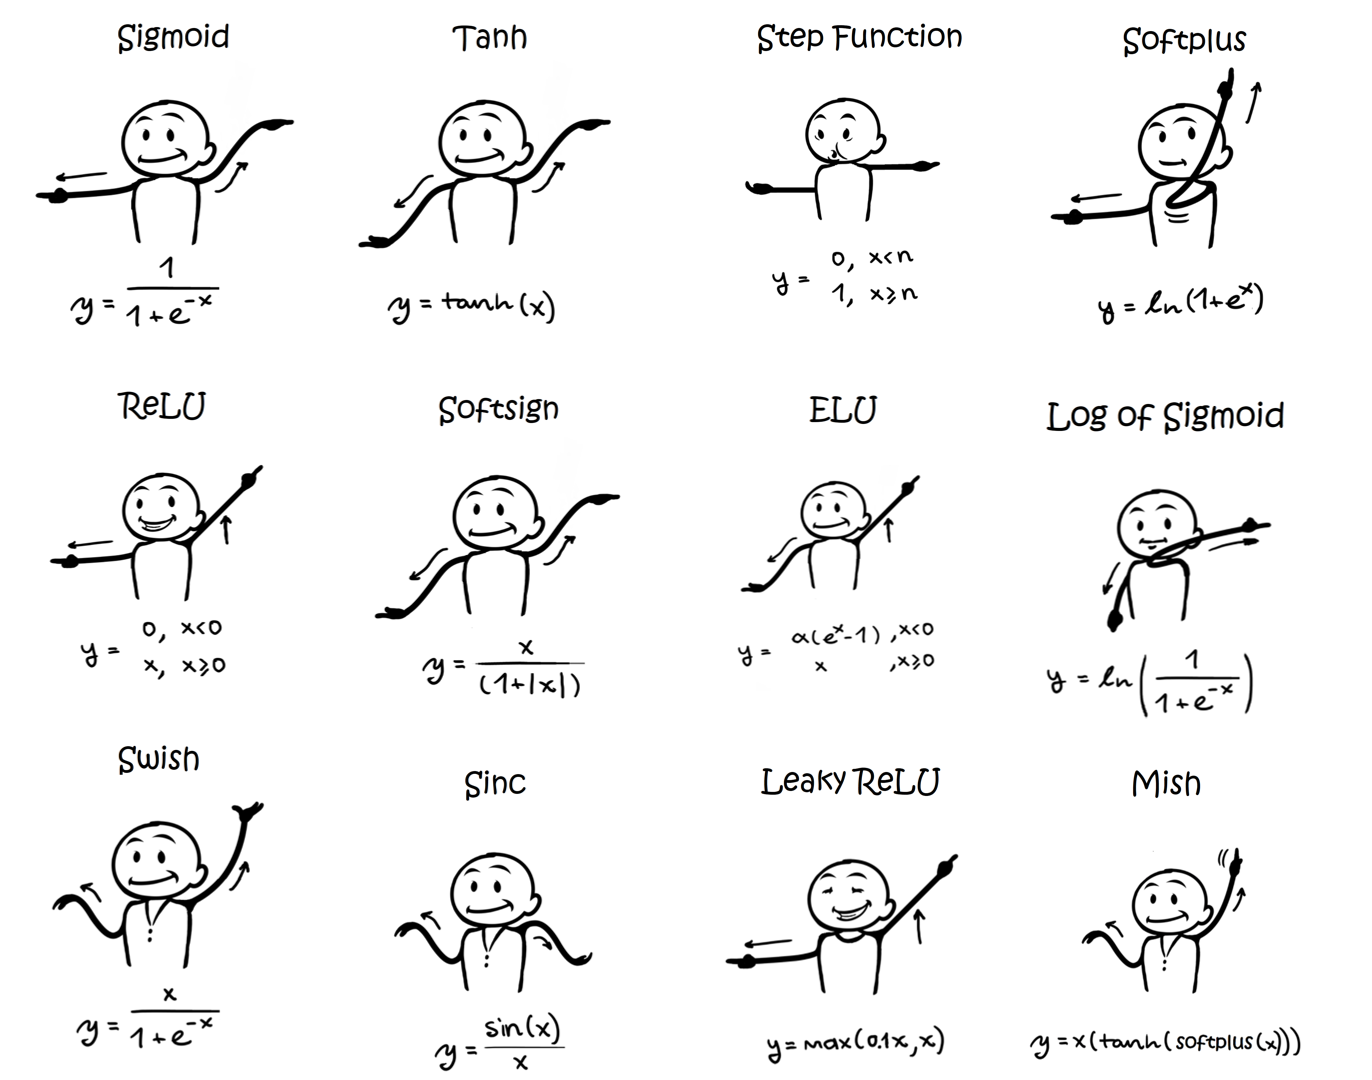

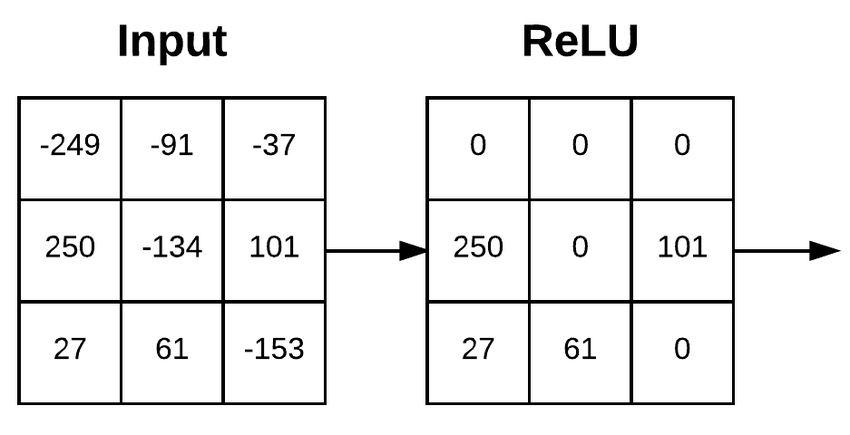

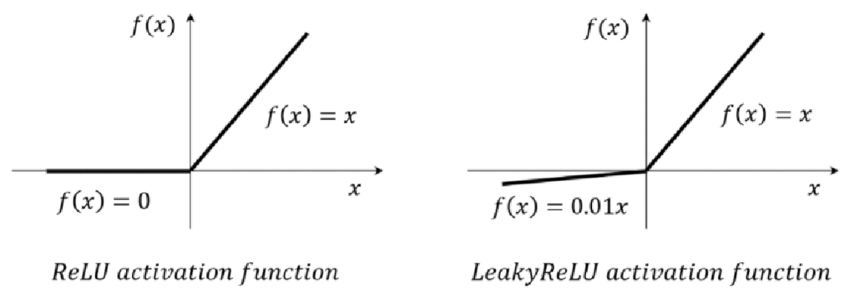

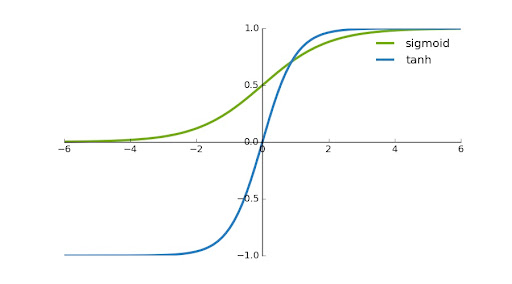



## 🔹 1. Definition and Formula

The **tanh function** is a *non-linear activation function* used in neural networks, especially in hidden layers.

Mathematically, it is defined as:

$$
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
$$

It transforms any real number ( x ) into a range between **-1 and 1**.

---

### 🔸 Alternate Representation

It can also be written in terms of the **sigmoid** function ( \sigma(x) = \frac{1}{1 + e^{-x}} ):

$$
\tanh(x) = 2\sigma(2x) - 1
$$

So, it’s like a “shifted and scaled” sigmoid.

---

## 🔹 2. Graph and Intuition

| Region            | Behavior            |
| ----------------- | ------------------- |
| ( x \to -\infty ) | ( \tanh(x) \to -1 ) |
| ( x = 0 )         | ( \tanh(x) = 0 )    |
| ( x \to +\infty ) | ( \tanh(x) \to +1 ) |

So, **small negative inputs** become values close to **-1**,
and **large positive inputs** become values close to **+1**.

---

### 🧩 Intuitive Meaning:

Think of `tanh` as a **squashing function** that:

* Compresses wide-ranging input values into a smaller scale (−1 to 1)
* Keeps the *sign* (positive or negative) of the input
* Centers data around **0**, unlike the sigmoid which is centered around **0.5**

---

## 🔹 3. Derivative (for Backpropagation)

For gradient-based learning, the derivative of ( \tanh(x) ) is crucial:

$$
\frac{d}{dx} \tanh(x) = 1 - \tanh^2(x)
$$

This is simple and computationally efficient — one of the reasons tanh became popular before ReLU.

---

### Example:

Let’s compute for ( x = 1 ):

1️⃣ Compute the tanh value:

$$
\tanh(1) = \frac{e^1 - e^{-1}}{e^1 + e^{-1}} = \frac{2.718 - 0.368}{2.718 + 0.368} = 0.761
$$

2️⃣ Derivative:

$$
1 - \tanh^2(1) = 1 - (0.761)^2 = 1 - 0.579 = 0.421
$$

So, the gradient at ( x = 1 ) is **0.421**.

---

## 🔹 4. When to Use `tanh`

✅ **Use tanh when:**

* You want the output to be **centered around 0** (helps optimization)
* Inputs can be **both positive and negative**
* It’s a **hidden layer** in a small or traditional network (like RNNs)

---

### 💼 Industry Perspective:

* **Used in RNNs (Recurrent Neural Networks)** before LSTMs/GRUs became popular.
* Still used inside **LSTM** gates — the “cell state” update uses `tanh`.
* Common in some **autoencoders**, **signal processing models**, and **control systems** where bounded output is needed.
* In some regression problems, you can use tanh in the last layer to bound outputs in [-1, 1].

---

## 🔹 5. Advantages of `tanh`

| Advantage                        | Description                                                                             |
| -------------------------------- | --------------------------------------------------------------------------------------- |
| ✅ **Zero-centered output**       | Unlike sigmoid (0–1), tanh outputs are centered around 0, making optimization smoother. |
| ✅ **Stronger gradients**         | Steeper slope around 0 means better learning for mid-range values.                      |
| ✅ **Good for normalized inputs** | Works well when data is normalized (mean ≈ 0).                                          |
| ✅ **Smooth and differentiable**  | Continuous and has simple derivative — great for gradient-based learning.               |

---

## 🔹 6. Disadvantages of `tanh`

| Disadvantage                        | Description                                                                     |   |                                                      |
| ----------------------------------- | ------------------------------------------------------------------------------- | - | ---------------------------------------------------- |
| ⚠️ **Vanishing gradients**          | For large                                                                       | x | , gradients become near 0 → slows or stops learning. |
| ⚠️ **Computation cost**             | Slightly more expensive than ReLU due to exponentials.                          |   |                                                      |
| ⚠️ **Less effective for deep nets** | ReLU family (ReLU, Leaky ReLU, GELU) works better in modern deep architectures. |   |                                                      |

---

## 🔹 7. Comparison with Sigmoid and ReLU

| Property        | Sigmoid          | **tanh**                  | ReLU             |   |                     |
| --------------- | ---------------- | ------------------------- | ---------------- | - | ------------------- |
| Output range    | (0, 1)           | **(-1, 1)**               | (0, ∞)           |   |                     |
| Centered?       | ❌ No             | ✅ Yes                     | ✅ Yes            |   |                     |
| Saturation      | High             | High                      | Only for x < 0   |   |                     |
| Gradient issues | Vanishes quickly | Vanishes for large        | x                |   | Dies for negative x |
| Computation     | Moderate         | Moderate                  | Fast             |   |                     |
| Use case        | Binary output    | Hidden layers in old nets | Modern deep nets |   |                     |

---

## 🔹 8. Practical Example

Let’s see it in Python:

```python
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.tanh(x)
dy = 1 - np.tanh(x)**2

plt.figure(figsize=(7,4))
plt.plot(x, y, label='tanh(x)')
plt.plot(x, dy, label="tanh'(x)", linestyle='--')
plt.legend()
plt.title("tanh Activation and its Derivative")
plt.grid(True)
plt.show()
```

This will show:

* A smooth S-curve from -1 → +1 for tanh
* A bell-shaped derivative curve peaking at x = 0

---

## 🔹 9. Summary (Industry Cheat Sheet)

| Use Case                           | Recommended Activation           |
| ---------------------------------- | -------------------------------- |
| Traditional ML (shallow nets)      | `tanh` or `sigmoid`              |
| RNNs / LSTMs                       | `tanh` (still used inside cells) |
| Deep CNNs / Transformers           | `ReLU`, `LeakyReLU`, `GELU`      |
| Normalized input around 0          | `tanh` works great               |
| Speed-critical, large-scale models | Prefer `ReLU` family             |






# 🧠 What is Early Stopping?

**Early Stopping** is a technique to **stop training a model before it starts overfitting**.

---

## 🪴 Think of it like this:

Imagine you’re watering a plant 🌱.

* If you **stop too early**, the plant doesn’t grow enough.
  → (Underfitting — the model hasn’t learned well yet)

* If you **keep watering too long**, the plant’s roots rot.
  → (Overfitting — the model memorizes noise, not patterns)

**Early Stopping** helps you find the **sweet spot** 🌼 —
when the plant (your model) has learned *enough* but *not too much*.

---

## 📉 The Basic Idea

When you train a neural network:

* The **training loss** keeps decreasing (it’s learning the training data).
* The **validation loss** first decreases, then starts increasing (it’s beginning to overfit).

Early Stopping says:

> “⏹ Stop training when the **validation loss starts getting worse**.”

---

### 🔹 Example:

| Epoch | Training Loss ↓ | Validation Loss ↓ |
| :---: | :-------------: | :---------------: |
|   1   |       1.2       |        1.1        |
|   2   |       0.8       |        0.7        |
|   3   |       0.5       |        0.5        |
|   4   |       0.3       |       0.6 ❗       |
|   5   |       0.2       |       0.8 ❗       |

👉 Validation loss went **up at epoch 4**,
so Early Stopping will **stop training** after epoch 3.

---

## 🧮 How It Works (Step-by-Step)

1. You **split data** into:

   * Training set (used to learn)
   * Validation set (used to check performance)

2. During training:

   * You monitor validation loss (or accuracy)
   * Keep track of the **best epoch**

3. If validation loss doesn’t improve for a few rounds (say, 3–5 epochs),
   → **Stop training** and **restore** the best model weights.

---

## 🧠 Real-World Analogy

You’re studying for an exam:

* You take practice tests every day.
* Your scores keep improving.
* But after too much studying, you start getting tired and your score drops.

👉 **Early stopping** means **stop studying right before you start forgetting**.

---

## ⚙️ Implementation (Example in Keras)

```python
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',     # what to watch
    patience=3,             # stop if no improvement for 3 epochs
    restore_best_weights=True
)

model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=50,
          callbacks=[early_stop])
```

✅ This will stop training automatically at the best point.

---

## ✅ Advantages

| 👍 Benefit                            | Explanation                              |
| ------------------------------------- | ---------------------------------------- |
| **Prevents overfitting**              | Stops before model memorizes noise       |
| **Saves time**                        | No need to train for all 100 epochs      |
| **No extra cost**                     | Doesn’t need new data or hyperparameters |
| **Works with any optimizer or model** | Universal concept                        |

---

## ⚠️ Disadvantages

| ⚠️ Limitation                              | Explanation                                               |
| ------------------------------------------ | --------------------------------------------------------- |
| **Might stop too early**                   | If validation fluctuates slightly, it might quit too soon |
| **Needs validation data**                  | Must have a separate validation set                       |
| **Not helpful with noisy validation loss** | If your validation metric jumps around, it’s tricky       |

---

## 🧩 In Short

| Concept    | Meaning                                      |
| ---------- | -------------------------------------------- |
| Goal       | Stop training at the best validation point   |
| Helps With | Overfitting, wasted training time            |
| Common In  | Neural networks, deep learning models        |
| Analogy    | “Stop watering when the plant is healthy” 🌱 |

---

## 💡 TL;DR Summary

> **Early Stopping** = Stop training **when performance on validation data stops improving**,
> to avoid **overfitting** and save **time** ⏳.





# 🧠 What is **Dropout**?

**Dropout** is a **regularization technique** used to **prevent overfitting** in neural networks.

It works by **randomly turning off some neurons during training** —
so the network doesn’t become too dependent on any one neuron.

---

## 🎯 Intuitive Example

Imagine a classroom of students 👩‍🎓👨‍🎓 working on a group project.

* If **every student participates**, some might rely on the smart kid to do all the work (overfitting!).
* If **randomly some students are absent each day**,
  everyone learns to contribute because they can’t depend on the same people every time.

✅ **Dropout works the same way** — each neuron learns to work independently, making the model more robust.

---

## 🔹 How It Works (Conceptually)

### During **Training**:

* For each batch of data:

  * Each neuron has a probability ( p ) (like 0.5) of being **“dropped out”** (turned off temporarily).
  * Those neurons don’t send output or receive weight updates.
  * Remaining neurons are **scaled up** to maintain overall balance.

### During **Testing** (or inference):

* **No neurons are dropped.**
* Instead, all neurons are active, but their outputs are **scaled down** (multiplied by dropout probability ( p ))
  to match the expected values from training.

---

## 🔹 The Math (Simple)

Let’s say:

* ( h_i ) = output of neuron *i* before dropout
* ( r_i ) = random binary mask (1 = keep, 0 = drop)
* ( p ) = keep probability (e.g., 0.8 means 80% neurons stay active)

Then during **training**:

$$
\tilde{h_i} = \frac{r_i}{p} \cdot h_i
$$

This scaling by ( \frac{1}{p} ) ensures that the expected sum of activations stays the same.

During **testing**:

$$
h_i^{test} = h_i
$$

But since we scaled during training, we don’t need to scale here — outputs remain balanced.

---

## 🔸 Example (Step-by-Step)

Suppose you have **4 neurons** in a hidden layer:

```
[0.3, 0.5, 0.9, 0.2]
```

Dropout rate = 0.5 (so keep probability p = 0.5)

### 🏋️‍♀️ During Training:

Randomly turn off half of them:

```
Mask (r_i): [1, 0, 1, 0]
```

Apply the formula:

```
output = (r_i / p) * h_i = ([1, 0, 1, 0] / 0.5) * [0.3, 0.5, 0.9, 0.2]
        = [0.6, 0, 1.8, 0]
```

So only neuron 1 and 3 are active, but **scaled up** to keep total energy same.

### 🧮 During Testing:

No dropout → all neurons active, but **no scaling needed**, because we already adjusted for it during training.

Output:

```
[0.3, 0.5, 0.9, 0.2]
```

---

## 🔹 When Neurons Are “Not Active”

When a neuron is **dropped out (r_i = 0)**:

* Its **output = 0** for that batch.
* It **does not participate** in forward pass or backpropagation.
* Its **weights are not updated** during that batch.

👉 But next batch, it might be active again!
This randomness helps neurons **not depend** on each other too much.

---

## 🔹 Why Dropout Helps

Without dropout:

* The network can **memorize** training data (overfitting).

With dropout:

* Each neuron must learn to be **useful on its own**, even when others disappear.
* It’s like training **many smaller networks** at once, then averaging them at test time.

---

## 🔹 Example in Keras

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu'),
    Dropout(0.5),  # 50% neurons dropped during training
    Dense(64, activation='relu'),
    Dropout(0.3),  # 30% neurons dropped
    Dense(10, activation='softmax')
])
```

When you call `model.fit()`, dropout is applied automatically **only during training**.
When you call `model.evaluate()` or `model.predict()`, dropout is **turned off**.

---

## 🔹 Visual Intuition

```
Without Dropout
   Layer:  ● ● ● ●
             ↓ ↓ ↓ ↓
           [All neurons active every time]

With Dropout (p=0.5)
   Layer:  ● ⭕ ● ⭕
             ↓   ↓
       [Some neurons turned off each batch]
```

---

## 🔹 Advantages

| ✅ Advantage                   | Explanation                                |
| ----------------------------- | ------------------------------------------ |
| **Prevents overfitting**      | Neurons can’t rely on each other too much  |
| **Simple to implement**       | Just one line of code                      |
| **Acts like model averaging** | Behaves like an ensemble of smaller models |
| **Improves generalization**   | Performs better on unseen data             |

---

## 🔹 Disadvantages

| ⚠️ Disadvantage           | Explanation                                                            |
| ------------------------- | ---------------------------------------------------------------------- |
| **Longer training time**  | Random dropout slows convergence                                       |
| **Not always needed**     | Modern methods (BatchNorm, regularization) sometimes make it redundant |
| **Can hurt small models** | If you drop too many neurons, the model can underfit                   |

---

## 🔹 When to Use Dropout (Industry Perspective)

| Scenario                               | Use Dropout? | Why                               |
| -------------------------------------- | ------------ | --------------------------------- |
| Deep networks (CNN, RNN, Transformers) | ✅ Yes        | Helps generalize                  |
| Small/simple models                    | ⚠️ Maybe     | Could underfit                    |
| With Batch Normalization               | ⚠️ Careful   | Often redundant or less effective |
| During inference (test/predict)        | ❌ Never      | Dropout only during training      |

---

## 🔹 TL;DR Summary

| Concept  | Meaning                                    |
| -------- | ------------------------------------------ |
| What     | Randomly turns off neurons during training |
| Why      | Prevents overfitting                       |
| Training | Neurons dropped randomly + scaled up       |
| Testing  | All neurons active, no scaling             |
| Benefit  | Makes the model generalize better          |

---

## 💡 One-Line Analogy

> “Dropout is like sending different team members to practice each day — so everyone learns to play well individually, and the whole team performs better on game day.” 🏆




Got it ✅ — here’s a **Google Colab–friendly** version that will render math **perfectly**.
In Colab text cells, you must use **single dollar signs `$...$` for inline math** and
**double dollar signs `$$...$$` for display math** — this version uses that rule correctly.

Just copy-paste this **as a text cell** in Colab — it will look perfect.

---

# 🧠 Dropout — Simple Example for $w(1 - p)$ (Classic Dropout)

---

## 🎯 Goal

Understand how dropout changes the weight during **testing**
using the formula $w_{\text{test}} = w(1 - p)$.

---

## 🔹 Setup

Simplest possible model:

$$
y = w \times x
$$

Given:

* $x = 10$
* $w = 2$
* Dropout rate $= 0.5 \Rightarrow p = 1 - 0.5 = 0.5$

---

## 🔹 Step 1 — During Training

Each neuron has a **50 % chance** to be dropped.

### Case 1 — Neuron kept

$$
y = w \times x = 2 \times 10 = 20
$$

### Case 2 — Neuron dropped

$$
y = 0
$$

---

## 🔹 Step 2 — Average Output During Training

Half the time output = 20, half the time = 0:

$$
E[y_{\text{train}}] = 0.5 \times 20 + 0.5 \times 0 = 10
$$

✅ **Expected training output = 10**

---

## 🔹 Step 3 — During Testing (No Dropout)

Now **all neurons are active**.

If we keep the same weight $w=2$:

$$
y_{\text{test}} = 2 \times 10 = 20
$$

😕 That’s **too large** compared to the expected training output (10).

---

## 🔹 Step 4 — Scale the Weight by $p$

To fix this, scale down the weights at test time:

$$
w_{\text{test}} = w \times p = 2 \times 0.5 = 1
$$

Now:

$$
y_{\text{test}} = 1 \times 10 = 10
$$

✅ Perfect — the **test output (10)** now matches the **average training output (10)**.

---

## 🧩 Summary

|     Phase    |  Active Neurons  |                  Formula                  |  Output |
| :----------: | :--------------: | :---------------------------------------: | :-----: |
| **Training** | Randomly dropped | $y = r \cdot w \cdot x,; r=0\text{ or }1$ | 0 or 20 |
|  **Testing** |    All active    |         $y = (w \times p) \cdot x$        |    10   |

---

## ✅ Final Intuition

* **Training:** randomly turn off neurons → some outputs = 0.
* **Testing:** all neurons active → scale down weights by $p = 1-\text{dropout rate}$
  to keep outputs consistent.

---

## 🧮 Formula Recap

$$
\text{At test time:}\quad w_{\text{test}} = w \times (1 - \text{dropout rate})
$$

$$
\text{or equivalently:}\quad w_{\text{test}} = w \times p
$$

---

✅ **Summary:**
Classic dropout scales **weights at test time** by $p$.
Modern frameworks (TensorFlow / PyTorch) instead scale **during training**,
which is called **Inverted Dropout**.




# 🧠 Weight Initialization — Simple, Clear Explanation (with Xavier & He Normal)

---

## 🔹 Why Initialization Matters

When we train deep networks, each layer passes signals forward and backward.
If weights start too big → activations or gradients **explode** 💥
If too small → they **vanish** (become almost zero).

Good initialization keeps the **variance** of signals roughly stable through layers.

---

## 🔹 Definitions

Let each layer have:

* **fan_in** = number of inputs (neurons feeding into this layer)
* **fan_out** = number of outputs (neurons this layer feeds into)

---

## 🧮 1. Xavier (Glorot) Normal Initialization

**Purpose:** Works well for **tanh**, **sigmoid**, or **linear** activations.

Formula:

$$
W_{ij} \sim \mathcal{N}\left(0, \sigma^2\right), \quad \sigma = \sqrt{\frac{2}{\text{fan_in} + \text{fan_out}}}
$$

✅ Keeps activations and gradients balanced for symmetric activations.

---

### 🔸 Example:

Suppose:

* Inputs = 128  →  fan_in = 128
* Outputs = 64  →  fan_out = 64

Then:

$$
\sigma = \sqrt{\frac{2}{128 + 64}} = \sqrt{\frac{2}{192}} = 0.102
$$

So weights come from a **normal distribution**:
[
W \sim \mathcal{N}(0, 0.102^2)
]

---

## 🧮 2. He (Kaiming) Normal Initialization

**Purpose:** Designed for **ReLU**, **Leaky ReLU**, and other ReLU-like activations.
ReLU zeros out about half of the inputs → we need **larger variance** to balance.

Formula:

$$
W_{ij} \sim \mathcal{N}\left(0, \sigma^2\right), \quad \sigma = \sqrt{\frac{2}{\text{fan_in}}}
$$

✅ Keeps variance stable after ReLU.

---

### 🔸 Example:

Same layer:

* fan_in = 128
  Then:

$$
\sigma = \sqrt{\frac{2}{128}} = 0.125
$$

So:

[
W \sim \mathcal{N}(0, 0.125^2)
]

👉 He gives slightly **larger std** than Xavier to compensate for ReLU zeros.

---

## 🧩 3. Which to Use?

| Activation Function               | Recommended Init | Formula (Normal)                                         |
| --------------------------------- | ---------------- | -------------------------------------------------------- |
| **ReLU / LeakyReLU / GELU / ELU** | He Normal        | ( \sigma = \sqrt{2 / \text{fan_in}} )                    |
| **tanh / sigmoid / linear**       | Xavier Normal    | ( \sigma = \sqrt{2 / (\text{fan_in} + \text{fan_out})} ) |
| **SELU**                          | LeCun Normal     | ( \sigma = \sqrt{1 / \text{fan_in}} )                    |

---

## ⚙️ 4. Code Examples

### PyTorch

```python
import torch
import torch.nn as nn

# Xavier Normal for tanh/sigmoid
layer_tanh = nn.Linear(128, 64)
nn.init.xavier_normal_(layer_tanh.weight)
nn.init.zeros_(layer_tanh.bias)

# He Normal for ReLU
layer_relu = nn.Linear(128, 64)
nn.init.kaiming_normal_(layer_relu.weight, mode='fan_in', nonlinearity='relu')
nn.init.zeros_(layer_relu.bias)
```

---

### TensorFlow / Keras

```python
from tensorflow.keras import layers, initializers

# Xavier Normal (GlorotNormal)
xavier_layer = layers.Dense(
    64, activation='tanh',
    kernel_initializer=initializers.GlorotNormal(),
    bias_initializer='zeros'
)

# He Normal (HeNormal)
he_layer = layers.Dense(
    64, activation='relu',
    kernel_initializer=initializers.HeNormal(),
    bias_initializer='zeros'
)
```

---

## 💡 5. Bias Initialization

Bias terms are usually set to **0**.
They shift activations but don’t affect variance much.

---

## 🧠 6. Quick Sanity Check (1 Neuron Example)

For a ReLU neuron:

* fan_in = 100
* Inputs ~ Normal(0, 1)

He normal →
[
Var(w) = \frac{2}{100} = 0.02
]

Variance of activation:
[
Var(z) = 100 \times 0.02 \times 1 = 2
]

After ReLU (about half zeros):
[
Var(\text{output}) \approx 1
]

✅ Output variance stays stable — that’s the whole goal!

---

## ⚠️ 7. Tips & Pitfalls

| Common Issue                   | Solution                             |
| ------------------------------ | ------------------------------------ |
| Using Xavier for ReLU networks | Use He Normal instead                |
| Using random small weights     | Causes vanishing gradients           |
| Using large weights            | Causes exploding activations         |
| Using BatchNorm                | Still good to combine with He/Xavier |
| Bias init non-zero             | Usually unnecessary, use 0           |

---

## ✅ TL;DR Summary

| Initialization    | Use With       | Formula                                         | Keeps Variance Stable     |
| ----------------- | -------------- | ----------------------------------------------- | ------------------------- |
| **Xavier Normal** | tanh / sigmoid | ( \sqrt{2 / (\text{fan_in} + \text{fan_out})} ) | For symmetric activations |
| **He Normal**     | ReLU family    | ( \sqrt{2 / \text{fan_in}} )                    | For ReLU-like activations |

---

### 📌 One-Line Intuition

> **Xavier:** balanced signals both ways
> **He:** boosts variance to counter ReLU zeros





# 🚀 Gradient Descent: Batch vs Mini-Batch vs Stochastic (SGD)

We will learn a single weight ( w ) using a tiny dataset.

---

## 🔢 Dataset

| (x) | (y) |
| :-: | :-: |
|  1  |  2  |
|  2  |  4  |
|  3  |  6  |

We want to minimize:

$$
L(w) = \frac{1}{2}\sum (wx_i - y_i)^2
$$

We start with:

$$
w = 0, \quad \eta = 0.1
$$

(Optimal ( w = 2 ), since ( y = 2x ))

---

## 🟦 1. Batch Gradient Descent

➡️ Uses **all samples** to compute gradient each update.

Gradient formula:

$$
\nabla L(w) = \sum (wx_i - y_i)x_i
$$

At ( w = 0 ):

$$
\nabla L(0) = (0 - 2)(1) + (0 - 4)(2) + (0 - 6)(3)
$$

$$
\nabla L(0) = -2 - 8 - 18 = -28
$$

Update weight:

$$
w = w - \eta \cdot \nabla L(w)
$$

$$
w = 0 - 0.1(-28)
$$

$$
\boxed{w = 2.8}
$$

✅ Batch GD is **accurate but slow** (uses whole dataset at once)

---

## 🟦 2. Stochastic Gradient Descent (SGD)

➡️ Updates ( w ) **after every sample**

Update rule:

$$
w = w - \eta(wx_i - y_i)x_i
$$

Start again:

$$
w = 0
$$

---

### Sample (1,2)

$$
w = 0 - 0.1(0 - 2)(1)
$$

$$
w = 0.2
$$

---

### Sample (2,4)

$$
w = 0.2 - 0.1(0.4 - 4)(2)
$$

$$
w = 0.2 - 0.1(-3.6)(2)
$$

$$
w = 0.92
$$

---

### Sample (3,6)

$$
w = 0.92 - 0.1(2.76 - 6)(3)
$$

$$
w = 0.92 - 0.1(-3.24)(3)
$$

$$
\boxed{w = 1.912}
$$

✅ SGD is **fast but noisy** (zig-zag updates)

---

## 🟦 3. Mini-Batch Gradient Descent

➡️ Uses small groups of data

Batch size = **2**

* Batch 1 → (1,2), (2,4)
* Batch 2 → (3,6)

---

### Batch 1 gradient

$$
\nabla L(w) = (wx_1 - y_1)x_1 + (wx_2 - y_2)x_2
$$

$$
\nabla L(0) = (0 - 2)(1) + (0 - 4)(2)
$$

$$
\nabla L(0) = -2 - 8 = -10
$$

Update:

$$
w = 0 - 0.1(-10)
$$

$$
w = 1.0
$$

---

### Batch 2 gradient

$$
\nabla L(w) = (wx_3 - y_3)x_3
$$

$$
\nabla L(1.0) = (3 - 6)(3)
$$

$$
\nabla L(1.0) = -9
$$

Update:

$$
w = 1.0 - 0.1(-9)
$$

$$
\boxed{w = 1.9}
$$

✅ Mini-batch = best of both worlds (stable + fast)

---

## ✅ Final Comparison

| Method            | Final Weight (w) | Data used per update | Behavior        |
| :---------------- | :--------------: | :------------------: | :-------------- |
| **Batch GD**      |        2.8       |      All samples     | Slow but stable |
| **Mini-Batch GD** |        1.9       |   Group of samples   | Best balance    |
| **SGD**           |       1.912      |     Single sample    | Fast but noisy  |

---

## ✅ Python Code (Put in a Code Cell)

```python
import numpy as np

X = np.array([1, 2, 3])
y = np.array([2, 4, 6])
eta = 0.1

# Batch Gradient Descent
w = 0
grad = np.sum((w * X - y) * X)
w = w - eta * grad
print("Batch GD:", round(w, 3))

# SGD
w = 0
for xi, yi in zip(X, y):
    grad = (w * xi - yi) * xi
    w = w - eta * grad
print("SGD:", round(w, 3))

# Mini-batch GD (batch size 2)
w = 0
grad = np.sum((w * X[:2] - y[:2]) * X[:2])
w = w - eta * grad
grad = np.sum((w * X[2:] - y[2:]) * X[2:])
w = w - eta * grad
print("Mini-batch GD:", round(w, 3))
```

